# Demo: Alignment

In this notebook, I will demonstrate face alignment, a bit of common preparation for machine learning input. Alignment just means rotating a face until it's vertically oriented (no slant). We will then crop the rotated output to get it back to a standard rectangular shape.

Certain models (such as StyleGAN2) need their input faces to be aligned in order to process them. However, I think doing this for a stimulus set you *don't* plan on morphing is a good idea, simply as a standardization measure. I've found that the apparent emotion or character of a face seems to shift subtly depending on the angle.


## Materials

I prefer doing this work in virtual machines, as these tools are quite resource-intensive.

By connecting my Drive, I can also access resources I saved to it earlier; I can also save the stimuli I create for later use.

In [3]:
### Mount personal Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# FYI: First time you run this cell in a session, you'll get a permissions popup

Mounted at /content/drive


In [199]:
### Import dependencies
# building system (assembles collected source code into a linked system we can run)
# sort of like gestalt formation but for computers
!pip install ninja
import ninja

# specifying paths, file retrieval, copying
from pathlib import Path
from shutil import copy2
import os
import sys

# math, for rounding and a bit of geometry
import math
import numpy as np

# computer vision, image editing in general
import cv2
import dlib
import PIL
from PIL import Image

# data visualization (for displaying faces)
import matplotlib
import matplotlib.pyplot as plt


In [5]:
# Dlib is a machine learning library with some very useful pre-trained functions
# the ones we'll need are the face detector function, which we loaded above
detector = dlib.get_frontal_face_detector()

# and its shape predictor, which we'll need to pull from the dlib repository
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
# and then decompress
!bunzip2 "shape_predictor_68_face_landmarks.dat.bz2"
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

--2026-04-25 13:44:43--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-25 13:44:43--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  49.2MB/s    in 1.2s    

2026-04-25 13:44:44 (49.2 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



Our pictures for this runtime come from the Chicago Face Database (CFD).

The CFD has high-res images of men and women from a variety of demographics. It also includes norming data, which is a record of how a seperate set of participants evaluated each photo (Did the person seem sad? How attractive are they?). As a whole, the CFD and its ratings aren't especially well-controlled. All the same, this source is still a good start for a stimulus set.

In [176]:
### Source images
# Destination of unedited images for this session
# We don't want to accidentally overwrite the original files
!mkdir raw

# The folder where I'm storing my copy of the CFD
img_dir = "/content/drive/MyDrive/CFD"

# Specifying which faces to use, then copying each one over to raw/
# Inefficient, but let's save the regex stuff for when we do batch processing
raw_type = ".jpg" # known filetype

f1_dir = "WM-036" # white male #036
f1_name = "CFD-WM-036-031-N" # N = neutral expression
!cp "{img_dir}/{f1_dir}/{f1_name}{raw_type}" raw/

f2_dir = "AF-219" # asian female #219
f2_name = "CFD-AF-219-106-N" # N = neutral expression
!cp "{img_dir}/{f2_dir}/{f2_name}{raw_type}" raw/


# Did we successfully write to raw/?
!ls raw/

mkdir: cannot create directory ‘raw’: File exists
CFD-AF-219-106-N.jpg  CFD-WM-036-031-N.jpg


What do these Chicagoans look like, anyway? Note that both subjects in this demo tilted their head to the side slightly.

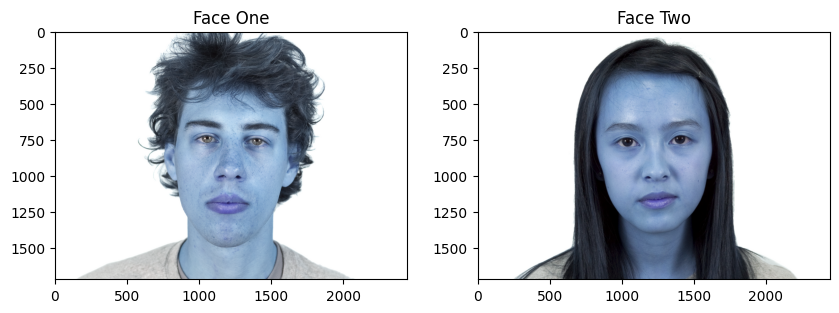

In [30]:
# Specify display size
plt.figure(figsize=(10, 5))

# Face One
image = cv2.imread(f"raw/{f1_name}{raw_type}")
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Face One')
plt.axis('on')

# Face Two
image = cv2.imread(f"raw/{f2_name}{raw_type}")
plt.subplot(1, 2, 2)
plt.imshow(image)
plt.title('Face Two')
plt.axis('on')

# Show all images in one window
plt.show()

*Woah,* what happened? I didn't know the CFD recruited the Blue Man Group.

OpenCV specifies color slightly differently from what we're used to. Instead of RGB, OpenCV uses BGR. When you read an image into OpenCV, it translates the color to the latter format. If we don't account for that when displaying or saving OpenCV output, our subjects will come out a little off.

Let's try this again:

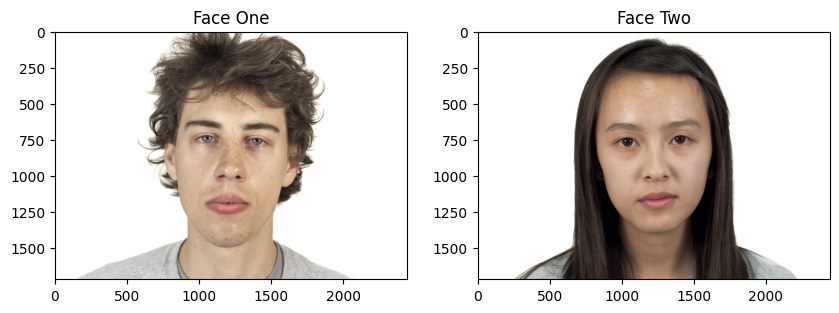

In [ ]:
# Specify display size
plt.figure(figsize=(10, 5))

# Face One
image = cv2.imread(f"raw/{f1_name}{raw_type}")
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) #convert color mapping
plt.title('Face One')
plt.axis('on')

# Face Two
image = cv2.imread(f"raw/{f2_name}{raw_type}")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) #convert color mapping
plt.title('Face Two')
plt.axis('on')

# Show all images in one window
plt.show()

## What are landmarks?
While Dlib's face detector function is self-explanatory, I think the shape predictor could use a bit more context (though keep in mind that I am no software engineer).

While there's a lot of subtle (and not-so-subtle) variation in facial features, certain aspects of their basic structure remain the same. For example, you can confidently predict that my nostrils are not above my eyebrows. So can a machine learning algorithm!

The shape predictor has been pre-trained on pictures of the human face so that when it's applied to a novel image, it can map its basic structure by identifying 68 key coordinates common across faces. Those coordinates are our landmarks, and finding them is key for rotation and cropping (plenty of other things too, but they're irrelevant at the moment).

Let's have a look at the landmarks for each of our faces!


In [8]:
# Simple landmarks-getting function using both dlib tools
# First, it finds all the faces present in the input
# Then, it gets a full set of coordinates for each

def get_landmarks(image):
    # the input image is also converted to grayscale for this
    # bit simpler to look for contrast that way
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)
    for face in faces:
        x1 = face.left()
        y1 = face.top()
        x2 = face.right()
        y2 = face.bottom()
        landmarks = predictor(gray, face)
    return landmarks

# We can then tell OpenCV to draw blue circles at those coordinates
def visualize_landmarks(image, landmarks):
  for n in range(0, 68):
          x = landmarks.part(n).x
          y = landmarks.part(n).y
          image2 = image
          cv2.circle(image2, (x, y), 12, (255, 0, 0), -1)
  return image2

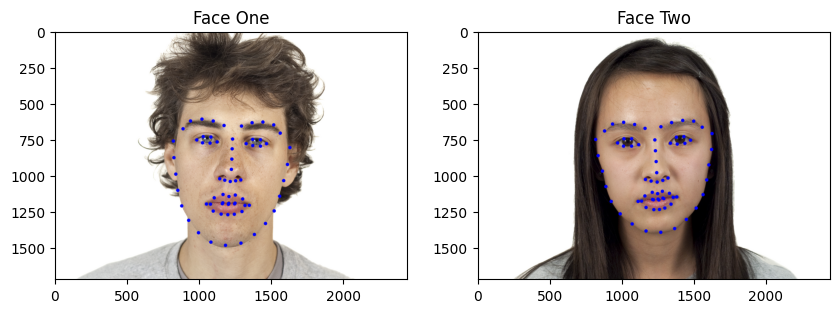

In [9]:
### Landmarks visualization
# Specify display size
plt.figure(figsize=(10, 5))

# Face One
image = cv2.imread(f"raw/{f1_name}{raw_type}")
coords = get_landmarks(image)
landmarks = visualize_landmarks(image, coords)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(landmarks, cv2.COLOR_BGR2RGB))
plt.title('Face One')
plt.axis('on')

# Face Two
image = cv2.imread(f"raw/{f2_name}{raw_type}")
coords = get_landmarks(image)
landmarks = visualize_landmarks(image, coords)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(landmarks, cv2.COLOR_BGR2RGB))
plt.title('Face Two')
plt.axis('on')

# Show all images in one window
plt.show()

## Rotation
Once we have the landmarks for a face's features, we can compare the position of one feature to that of another. For this rotation, we're comparing the eyes: if one eye is higher up than the other, then the face is most likely at an angle, as is the case with both of our CFD photos.

If we calculate exactly how *much* of an angle, we'll know the degree of rotation we need to adjust.



In [28]:
### Function that compares XY positions
def trignometry_for_distance(a, b):
    return math.sqrt(((b[0] - a[0]) * (b[0] - a[0])) +\
                     ((b[1] - a[1]) * (b[1] - a[1])))

Let's try this out. For now, don't worry about the cropping or border variables.


In [207]:
def align_face(image,cropImage,borderMode):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray, 1)

    if len(faces) == 0:
        return None  # No faces detected

    aligned_faces = []
    for face in faces:
        # Extract landmarks
        landmarks = predictor(gray, face)
        # Parse landmarks
        face_landmarks = [(item.x, item.y) for item in predictor(gray, face).parts()]
        # Convert to an array
        lm = np.array(face_landmarks)

        # Here's a rundown of where each feature is in the array
        # We  only need the eyes, so feel free to get rid of the others
        # pylint: disable=unused-variable

        lm_chin          = lm[0  : 17]  # left-right
        lm_eye_left      = lm[36 : 42]  # left-clockwise
        lm_eye_right     = lm[42 : 48]  # left-clockwise
        lm_eyebrow_left  = lm[17 : 22]  # left-right
        lm_eyebrow_right = lm[22 : 27]  # left-right
        lm_mouth_outer   = lm[48 : 60]  # left-clockwise
        lm_mouth_inner   = lm[60 : 68]  # left-clockwise
        lm_nose          = lm[27 : 31]  # top-down
        lm_nostrils      = lm[31 : 36]  # top-down

        # Get the center of each eye
        eye_left     = np.mean(lm_eye_left, axis=0)
        eye_right    = np.mean(lm_eye_right, axis=0)

        # Calculate a midpoint between features on the left and right
        # As well as how the eyes relate to the mouth (relevant to cropping)
        eye_avg      = (eye_left + eye_right) * 0.5
        eye_to_eye   = eye_right - eye_left
        mouth_left   = lm_mouth_outer[0]
        mouth_right  = lm_mouth_outer[6]
        mouth_avg    = (mouth_left + mouth_right) * 0.5
        eye_to_mouth = mouth_avg - eye_avg

        ### CALCULATE ROTATION
        # Decide rotation direction based on eye centers' vertical position
        # This is also where we pick a third point, which I'll explain shortly
        if eye_left[1] > eye_right[1]:
            # Rotate clockwise
            direction = -1
            point_3rd = (eye_right[0], eye_left[1])

        else:
            # Rotate counterclockwise
            direction = 1
            point_3rd = (eye_left[0], eye_right[1])

        # We'll be treating the center of each eye as one corner of a triangle
            # (hence the third point)
        # This allows us to apply trig functions to get our rotation angle

        a = trignometry_for_distance(eye_left,
                                     point_3rd)
        b = trignometry_for_distance(eye_right,
                                     point_3rd)
        c = trignometry_for_distance(eye_right,
                                     eye_left)

        cos_a = (b*b + c*c - a*a)/(2*b*c)
        angle = (np.arccos(cos_a) * 180) / math.pi

        # We apply that value based on the direction we got earlier
        if direction == -1: #clockwise
            angle = -(90-angle)
        else: #counter-clockwise
            angle = angle

        # APPLY ROTATION
        # Get the image dimensions
        h, w = image.shape[:2]
        # We need to specify a center point for the rotation
        # To keep it specific to the current face, let's use eye_avg

        # Finally, put it all together and transform the image
        rotation_matrix = cv2.getRotationMatrix2D(eye_avg, angle, 1.0)
        rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h),
                                      borderMode = borderMode)

        ### CROP TO FACE
        # if we're not actually cropping the rotated image, we can move on
        if cropImage == 0:
          aligned_faces.append(rotated_image)
        else: #otherwise...
            # Calculate border
            x = eye_to_eye - np.flipud(eye_to_mouth)
            x /= np.hypot(*x)
            x *= max(np.hypot(*eye_to_eye) * 2.0, np.hypot(*eye_to_mouth) * 1.8)
            y = np.flipud(x) * [-1, 1]
            c = eye_avg + eye_to_mouth * 0.1
            quad = np.stack([c - x - y, c - x + y, c + x + y, c + x - y])
            qsize = np.hypot(*x) * 2
            border = max(int(np.rint(qsize * 0.25)), 3)

            # Detect the face in the rotated image
            rotFace = detector(rotated_image, 1)

            # get rotated landmarks
            rot_landmarks = [(item.x, item.y) for item in predictor(rotated_image,
                                                            rotFace[0]).parts()]
            rlm = np.array(rot_landmarks)

            # Find the eyes again
            rlm_eye_left      = rlm[36 : 42]  # left-clockwise
            rlm_eye_right     = rlm[42 : 48]  # left-clockwise

            # Get center
            reye_left     = np.mean(rlm_eye_left, axis=0)
            reye_right    = np.mean(rlm_eye_right, axis=0)
            reye_avg      = (reye_left + reye_right) * 0.5

            # Calculate horizontal modifier
            h_dist = math.floor((rotFace[0].right()-
                                 rotFace[0].left())/2)+border

            #Tweak the bounding box specified by the detector
            #defining vertical modifiers such that i'm not cutting off the top
            #without going out of bounds, at least for this stimulus source
            newT = math.floor((rotFace[0].top()*0.025))
            newB = math.floor((rotFace[0].bottom()*1.975))

            newL = math.floor((reye_avg[0]-h_dist))
            newR = math.floor((reye_avg[0]+h_dist))

            # Crop the image to the detected face area
            aligned_face = rotated_image[newT:newB, newL:newR]
            #append to set
            aligned_faces.append(aligned_face)

    return aligned_faces

<Figure size 2000x2000 with 0 Axes>

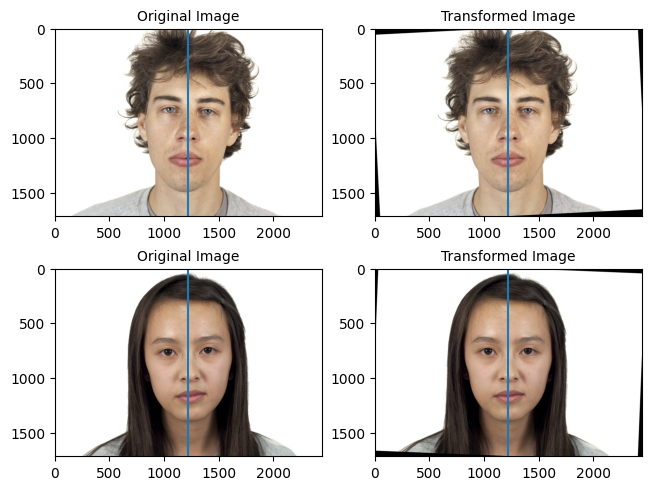

In [208]:
# Load the images
image1 = cv2.imread(f"raw/{f1_name}{raw_type}")
image2 = cv2.imread(f"raw/{f2_name}{raw_type}")

# Rotate the faces
aligned_faces1 = align_face(image1,cropImage=0,borderMode=0)
aligned_faces2 = align_face(image2,cropImage=0,borderMode=0)

# Convert from BGR to RGB
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
aligned_face1 = cv2.cvtColor(aligned_faces1[0],
                             cv2.COLOR_BGR2RGB)
aligned_face2 = cv2.cvtColor(aligned_faces2[0],
                             cv2.COLOR_BGR2RGB)

# Set up display
plt.figure(figsize=(20, 20))
plt.subplots(nrows=2, ncols=2, sharex=False,
             sharey=False, layout="constrained")
titlesize=10

# OGs
plt.subplot(2, 2, 1)
plt.imshow(image1)
plt.title('Original Image',fontsize=titlesize)
plt.axvline(x=math.floor(image1.shape[1]/2))

plt.subplot(2, 2, 3)
plt.imshow(image2)
plt.title('Original Image',fontsize=titlesize)
plt.axvline(x=math.floor(image2.shape[1]/2))

# Rotated versions
plt.subplot(2, 2, 2)
plt.imshow(aligned_face1)
plt.title('Transformed Image',fontsize=titlesize)
plt.axvline(x=math.floor(aligned_face1.shape[1]/2))

plt.subplot(2, 2, 4)
plt.imshow(aligned_face2)
plt.title('Transformed Image',fontsize=titlesize)
plt.axvline(x=math.floor(aligned_face2.shape[1]/2))

# Show all images in one window
plt.show()

Looking good! We don't need all that empty space on the sides, though. That requires some cropping. The bounding box I specified in this function is meant to preserve the subject's hair, shoulders, and other non-face traits. If your experiment only requires the face, get rid of the alterations I made to the "rotFace" coordinates.

We also need to do something about those unsightly edges. Fortunately, we can specify different ways for OpenCV's warp function to fill them in via the [borderMode](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#gga209f2f4869e304c82d07739337eae7c5aed2e4346047e265c8c5a6d0276dcd838) variable. I prefer to use the "replicate" method, which I think looks a bit more natural.

<Figure size 2000x2000 with 0 Axes>

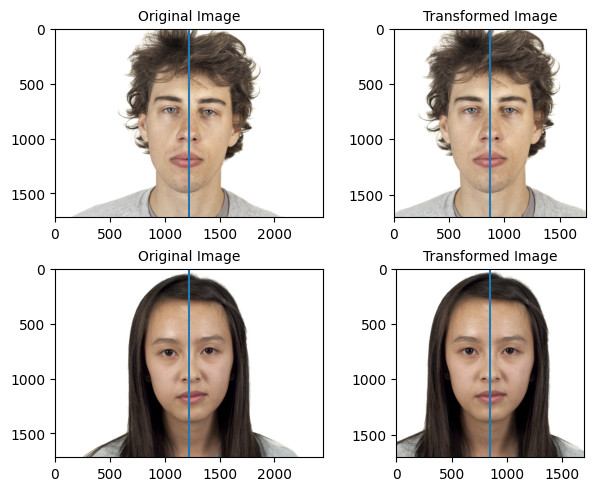

In [210]:
# Load the images
image1 = cv2.imread(f"raw/{f1_name}{raw_type}")
image2 = cv2.imread(f"raw/{f2_name}{raw_type}")

# Rotate the faces
aligned_faces1 = align_face(image1,cropImage=1,borderMode=1)
aligned_faces2 = align_face(image2,cropImage=1,borderMode=1)

# Convert from BGR to RGB
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
aligned_face1 = cv2.cvtColor(aligned_faces1[0],
                             cv2.COLOR_BGR2RGB)
aligned_face2 = cv2.cvtColor(aligned_faces2[0],
                             cv2.COLOR_BGR2RGB)

# Set up display
plt.figure(figsize=(20, 20))
plt.subplots(nrows=2, ncols=2, sharex=False,
             sharey=False, layout="constrained")
titlesize=10

# OGs
plt.subplot(2, 2, 1)
plt.imshow(image1)
plt.title('Original Image',fontsize=titlesize)
plt.axvline(x=math.floor(image1.shape[1]/2))

plt.subplot(2, 2, 3)
plt.imshow(image2)
plt.title('Original Image',fontsize=titlesize)
plt.axvline(x=math.floor(image2.shape[1]/2))

# Rotated versions
plt.subplot(2, 2, 2)
plt.imshow(aligned_face1)
plt.title('Transformed Image',fontsize=titlesize)
plt.axvline(x=math.floor(aligned_face1.shape[1]/2))

plt.subplot(2, 2, 4)
plt.imshow(aligned_face2)
plt.title('Transformed Image',fontsize=titlesize)
plt.axvline(x=math.floor(aligned_face2.shape[1]/2))

# Show all images in one window
plt.show()

And there we have it! Let's have a look at the aligned images without the reference line in the way.

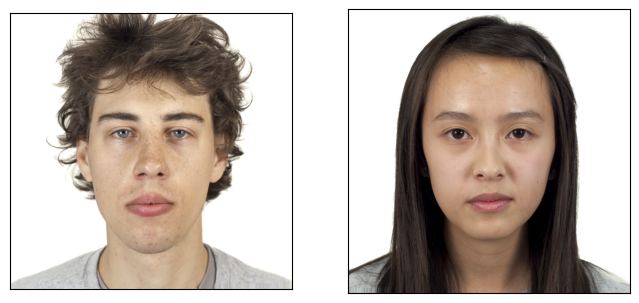

In [211]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.imshow(aligned_face1)
# border, but no ticks
ax = plt.gca()
ax.xaxis.set_visible(False)  # Hide X-axis
ax.yaxis.set_visible(False)  # Hide Y-axis

plt.subplot(1, 2, 2)
plt.imshow(aligned_face2)
# border, but no ticks
ax = plt.gca()
ax.xaxis.set_visible(False)  # Hide X-axis
ax.yaxis.set_visible(False)  # Hide Y-axis

# Show both images in one window
plt.show()

In [215]:
# First, let's save our output to a specific location
# Create aligned image folder, if it doesn't already exist
origin = "/content/aligned/"

if os.path.isdir(origin):
  cv2.imwrite(f"{origin}{f1_name}-A.png",
      cv2.cvtColor(aligned_face1, cv2.COLOR_BGR2RGB))
  cv2.imwrite(f"{origin}{f2_name}-A.png",
    cv2.cvtColor(aligned_face2, cv2.COLOR_BGR2RGB))
else:
  os.makedirs(origin)
  cv2.imwrite(f"{origin}{f1_name}-A.png",
      cv2.cvtColor(aligned_face1, cv2.COLOR_BGR2RGB))
  cv2.imwrite(f"{origin}{f2_name}-A.png",
    cv2.cvtColor(aligned_face2, cv2.COLOR_BGR2RGB))

!ls aligned

CFD-AF-219-106-N-A.png	CFD-WM-036-031-N-A.png


In [221]:
# Colab doesn't keep the files you make during a runtime
# if you need any for later, you'll want to copy them over to your drive

!cp -r /content/aligned/ /content/drive/MyDrive/Aligned/